# Neural Network Optimization Assignment

Data Preparation
Step 1 — Load Data

In [1]:
import pandas as pd

train_df = pd.read_csv("small_train.csv")
val_df = pd.read_csv("small_validation.csv")

Step 2 — Split Features and Labels

In [2]:
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_val = val_df.iloc[:, 1:].values
y_val = val_df.iloc[:, 0].values

Step 3 — Convert to Tensors

In [7]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

## Building the Neural Network
### One Hidden Layer Model

In [8]:
import torch.nn as nn

class OneHiddenNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, activation='relu'):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

        if activation == 'relu':
            self.activation = nn.ReLU()
        else:
            self.activation = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

### Two Hidden Layer Model

In [9]:
class TwoHiddenNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, activation='relu'):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

        if activation == 'relu':
            self.activation = nn.ReLU()
        else:
            self.activation = nn.Sigmoid()

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x

### Training Function

In [12]:
import torch.optim as optim

input_dim = 128
hidden_dim = 50
output_dim = 10

model = OneHiddenNN(input_dim, hidden_dim, output_dim)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

### Training Loop

In [30]:
train_losses = []
val_losses = []


for epoch in range(100):
    
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()

    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    val_losses.append(val_loss.item())

## QUESTION 1 — Hidden Units

In [32]:
hidden_units = [5, 20, 50, 100, 200]

train_final_losses = []
val_final_losses = []

for h in hidden_units:

    model = OneHiddenNN(input_dim, h, output_dim)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.003)

    train_losses = []
    val_losses = []

    for epoch in range(100):

        # TRAINING
        model.train()

        optimizer.zero_grad()

        outputs = model(X_train)

        loss = criterion(outputs, y_train)

        loss.backward()

        optimizer.step()

        # save training loss
        train_losses.append(loss.item())

        # VALIDATION
        model.eval()

        with torch.no_grad():

            val_outputs = model(X_val)

            val_loss = criterion(val_outputs, y_val)

        # save validation loss
        val_losses.append(val_loss.item())

    train_final_losses.append(train_losses[-1])
    val_final_losses.append(val_losses[-1])

### Plot

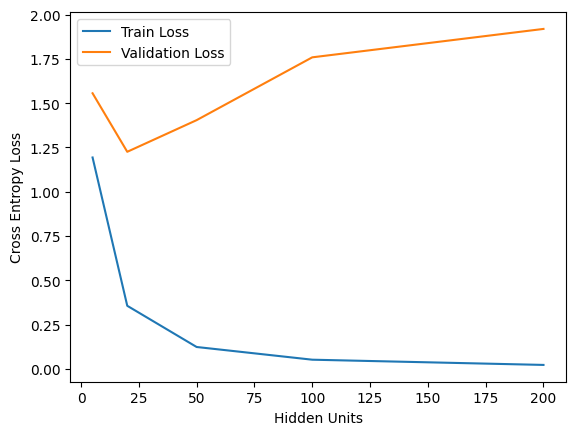

In [33]:
import matplotlib.pyplot as plt

plt.plot(hidden_units, train_final_losses, label='Train Loss')
plt.plot(hidden_units, val_final_losses, label='Validation Loss')

plt.xlabel('Hidden Units')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.show()

When the number of hidden units is too small, the neural network underfits the data because it lacks sufficient representational capacity to model the underlying patterns. As the number of hidden units increases, the model becomes more expressive and achieves lower training and validation losses. However, with too many hidden units, the model becomes overly complex and begins to overfit the small training dataset, causing validation performance to degrade despite improved training performance.

### QUESTION 2 — Weight Initialization

In [36]:
class OneHiddenNN(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


# PARAMETERS
input_dim = 128
hidden_dim = 50
output_dim = 10

# CREATE MODEL
model = OneHiddenNN(input_dim, hidden_dim, output_dim)


# ZERO INITIALIZATION
for param in model.parameters():
    nn.init.constant_(param, 0)
    # LOSS + OPTIMIZER
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

# TRAINING
for epoch in range(5):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

    # PRINT WEIGHTS
    print("\nfc1 weights:")
    print(model.fc1.weight)

    print("\nfc2 weights:")
    print(model.fc2.weight)

    print("-" * 50)


Epoch 1, Loss: 2.3025853633880615

fc1 weights:
Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)

fc2 weights:
Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

After initializing all weights to zero, the network failed to learn meaningful feature representations. The weights in both hidden and output layers remained nearly identical across neurons and stayed close to zero during training. This occurs because zero initialization creates symmetry between neurons, causing them to receive identical gradients and update identically. Additionally, using ReLU activation with zero inputs produces zero activations, which further prevents effective gradient flow. As a result, the network behaves like a much simpler model and fails to learn properly, as reflected by the loss remaining near 2.302, which corresponds to random guessing in a 10-class classification problem.

### QUESTION 3 — Adding Another Hidden Layer

In [38]:
# TRAINING FUNCTION
def train_model(model, X_train, y_train, X_val, y_val, epochs=100):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.003)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # TRAINING
        model.train()

        optimizer.zero_grad()

        outputs = model(X_train)

        loss = criterion(outputs, y_train)

        loss.backward()

        optimizer.step()

        train_losses.append(loss.item())

        # VALIDATION
        model.eval()

        with torch.no_grad():

            val_outputs = model(X_val)

            val_loss = criterion(val_outputs, y_val)

        val_losses.append(val_loss.item())

    return train_losses, val_losses

In [39]:
#Define Dimensions
input_dim = 128
hidden_dim = 50
output_dim = 10

In [40]:
# Train 1-hidden layer model
model1 = OneHiddenNN(input_dim, hidden_dim, output_dim)

train1, val1 = train_model(
    model1,
    X_train,
    y_train,
    X_val,
    y_val
)


In [41]:
# Train 2-hidden layer model
model2 = TwoHiddenNN(input_dim, hidden_dim, output_dim)

train2, val2 = train_model(
    model2,
    X_train,
    y_train,
    X_val,
    y_val
)

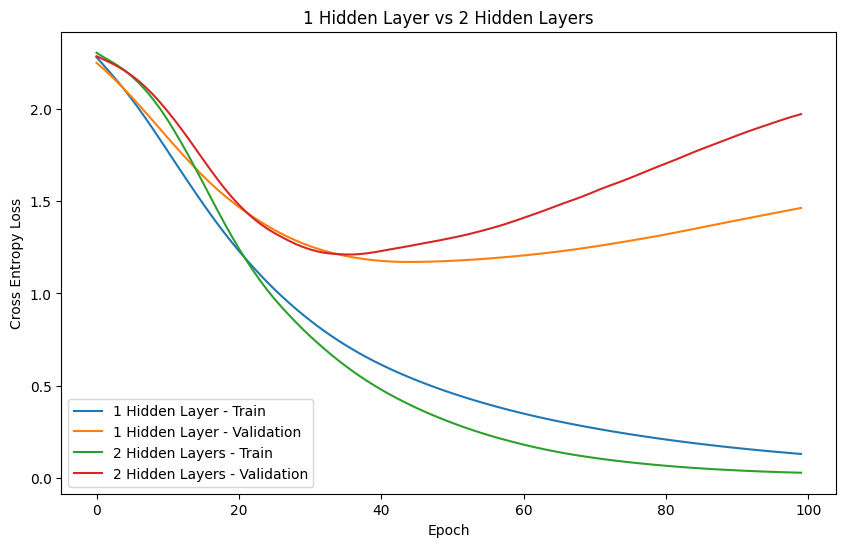

In [42]:
# Plot Results

plt.figure(figsize=(10,6))

plt.plot(train1, label='1 Hidden Layer - Train')
plt.plot(val1, label='1 Hidden Layer - Validation')

plt.plot(train2, label='2 Hidden Layers - Train')
plt.plot(val2, label='2 Hidden Layers - Validation')

plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')

plt.title('1 Hidden Layer vs 2 Hidden Layers')

plt.legend()

plt.show()

The two-hidden-layer neural network achieved a lower training loss compared to the one-hidden-layer model, indicating that the deeper architecture has greater representational capacity and can model more complex nonlinear relationships. However, the validation loss for the two-hidden-layer model increased more rapidly after the initial epochs, showing stronger overfitting behavior. This occurs because the deeper model contains more parameters and becomes overly specialized to the small training dataset, reducing its ability to generalize to unseen validation data. In contrast, the one-hidden-layer model exhibited more stable validation performance due to its lower complexity. Therefore, adding an additional hidden layer improves training performance but also increases the risk of overfitting on small datasets.

### QUESTION 4 — ReLU vs Sigmoid

One Hidden Layer Model with Selectable Activation

In [43]:
class OneHiddenNN(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim, activation='relu'):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

        if activation == 'relu':
            self.activation = nn.ReLU()

        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()

    def forward(self, x):

        x = self.fc1(x)

        x = self.activation(x)

        x = self.fc2(x)

        return x

In [44]:
# TRAINING FUNCTION
def train_model(model, X_train, y_train, X_val, y_val, epochs=100):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.003)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # TRAIN
        model.train()

        optimizer.zero_grad()

        outputs = model(X_train)

        loss = criterion(outputs, y_train)

        loss.backward()

        optimizer.step()

        train_losses.append(loss.item())

        # VALIDATION
        model.eval()

        with torch.no_grad():

            val_outputs = model(X_val)

            val_loss = criterion(val_outputs, y_val)

        val_losses.append(val_loss.item())

    return train_losses, val_losses

In [45]:
# Define Dimensions
input_dim = 128
hidden_dim = 50
output_dim = 10

In [ ]:
# Train ReLU activated model
relu_model = OneHiddenNN(
    input_dim,
    hidden_dim,
    output_dim,
    activation='relu'
)

relu_train, relu_val = train_model(
    relu_model,
    X_train,
    y_train,
    X_val,
    y_val
)

In [ ]:
# Train Sigmoid activated model
sigmoid_model = OneHiddenNN(
    input_dim,
    hidden_dim,
    output_dim,
    activation='sigmoid'
)

sigmoid_train, sigmoid_val = train_model(
    sigmoid_model,
    X_train,
    y_train,
    X_val,
    y_val
)

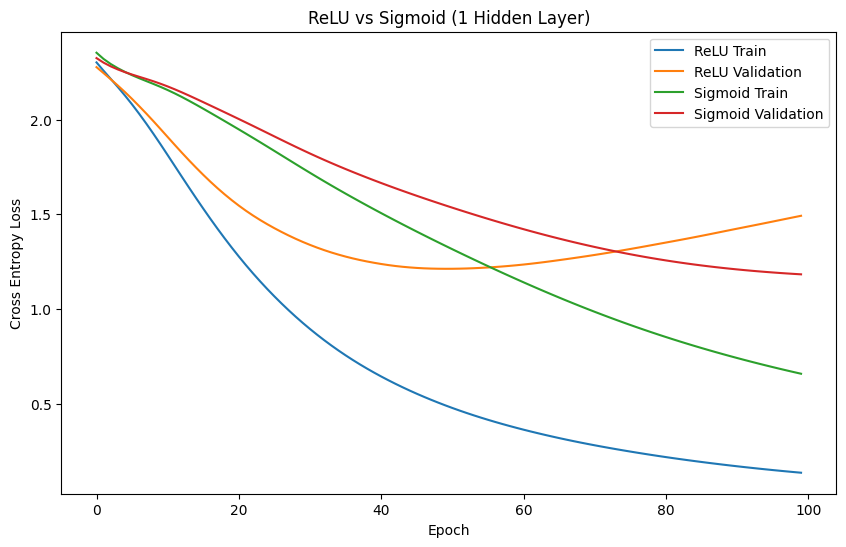

In [48]:
plt.figure(figsize=(10,6))

plt.plot(relu_train, label='ReLU Train')
plt.plot(relu_val, label='ReLU Validation')

plt.plot(sigmoid_train, label='Sigmoid Train')
plt.plot(sigmoid_val, label='Sigmoid Validation')

plt.xlabel('Epoch')

plt.ylabel('Cross Entropy Loss')

plt.title('ReLU vs Sigmoid (1 Hidden Layer)')

plt.legend()

plt.show()

The ReLU activation function converged significantly faster than the sigmoid activation function in the one-hidden-layer neural network. The ReLU model achieved a much lower training loss because it preserves stronger gradients during backpropagation, enabling more efficient optimization. In contrast, the sigmoid model learned more slowly due to the saturation property of the sigmoid function, which causes smaller gradients and slower parameter updates.
The ReLU network also exhibited stronger overfitting behavior, as shown by the increase in validation loss after approximately 50 epochs. Although the sigmoid network generalized more conservatively and showed less severe overfitting, it also underfit the training data compared to ReLU. Overall, ReLU provided better optimization performance and faster convergence for this task.

### QUESTION 5 — Two Hidden Layers + Activations

In [49]:
# Two Hidden Layer Model
class TwoHiddenNN(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim, activation='relu'):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

        if activation == 'relu':
            self.activation = nn.ReLU()

        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()

    def forward(self, x):

        x = self.activation(self.fc1(x))

        x = self.activation(self.fc2(x))

        x = self.fc3(x)

        return x

In [ ]:
#Relu Activated 2 Hidden Layer Model
relu_2_model = TwoHiddenNN(
    input_dim,
    hidden_dim,
    output_dim,
    activation='relu'
)

relu2_train, relu2_val = train_model(
    relu_2_model,
    X_train,
    y_train,
    X_val,
    y_val
)

In [ ]:
# Sigmoid Activated 2 Hidden Layer Model
sigmoid_2_model = TwoHiddenNN(
    input_dim,
    hidden_dim,
    output_dim,
    activation='sigmoid'
)

sigmoid2_train, sigmoid2_val = train_model(
    sigmoid_2_model,
    X_train,
    y_train,
    X_val,
    y_val
)

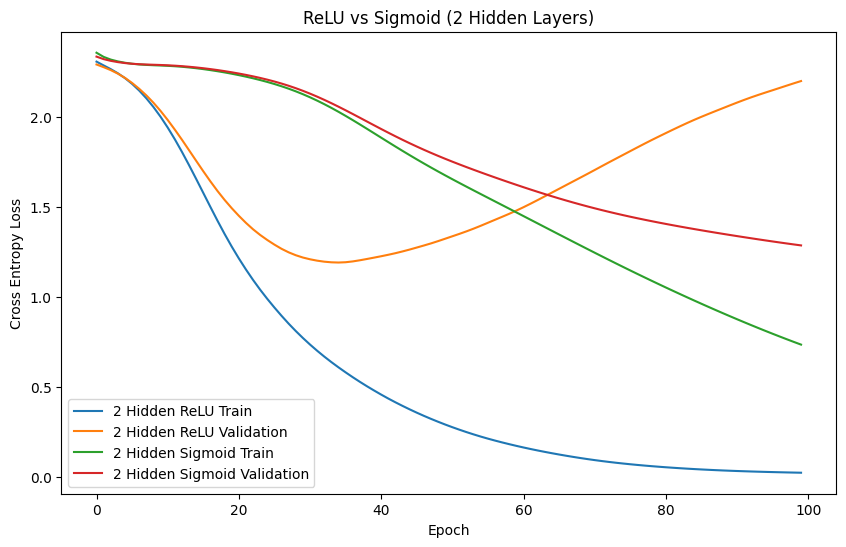

In [52]:
plt.figure(figsize=(10,6))

plt.plot(relu2_train, label='2 Hidden ReLU Train')
plt.plot(relu2_val, label='2 Hidden ReLU Validation')

plt.plot(sigmoid2_train, label='2 Hidden Sigmoid Train')
plt.plot(sigmoid2_val, label='2 Hidden Sigmoid Validation')

plt.xlabel('Epoch')

plt.ylabel('Cross Entropy Loss')

plt.title('ReLU vs Sigmoid (2 Hidden Layers)')

plt.legend()

plt.show()

The ReLU-based network converged significantly faster than the sigmoid-based network in the two-hidden-layer architecture. The ReLU model achieved a much lower training loss due to its ability to preserve stronger gradients during backpropagation, enabling more efficient optimization in deeper networks. In contrast, the sigmoid model exhibited much slower convergence because repeated sigmoid activations caused gradients to shrink across layers, leading to the vanishing gradient problem.\n\nAdditionally, the ReLU network demonstrated stronger overfitting behavior, as shown by the rapid increase in validation loss after the initial epochs. This occurred because the model learned the training data extremely well but generalized poorly to unseen validation data. The sigmoid model overfit less aggressively but also underfit more due to slower and weaker learning dynamics.\n\nThe performance gap between ReLU and sigmoid became more severe with two hidden layers, confirming that deeper sigmoid networks suffer more from vanishing gradients while ReLU remains more suitable for deep neural network optimization.